<a href="https://colab.research.google.com/github/NVHau-K14/Tuan2_ThucHanh_DeepLearning/blob/main/LinearRegession_Salary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch [100/1000] Loss: 0.007359
Epoch [200/1000] Loss: 0.003954
Epoch [300/1000] Loss: 0.003110
Epoch [400/1000] Loss: 0.002994
Epoch [500/1000] Loss: 0.002985
Epoch [600/1000] Loss: 0.002985
Epoch [700/1000] Loss: 0.002984
Epoch [800/1000] Loss: 0.002984
Epoch [900/1000] Loss: 0.002984
Epoch [1000/1000] Loss: 0.002984


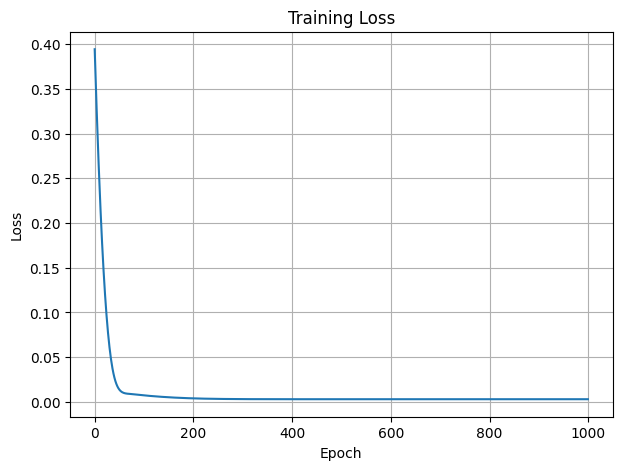


Test Loss: 0.005387745797634125
R2 Score: 0.8914227485656738

Phương trình:
Salary = 8578.75 × YearsExperience + 29078.72

Predicted Salary: 38515.348


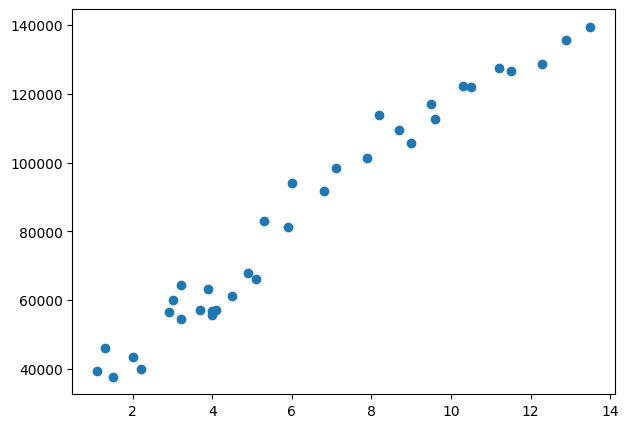

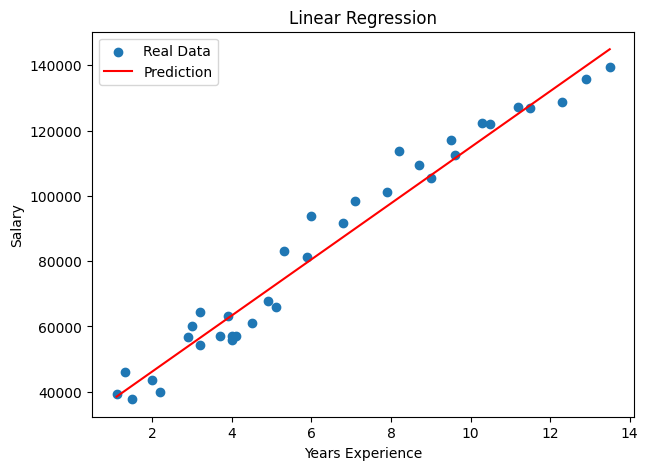

In [1]:
# ==========================================
# 1. IMPORT THƯ VIỆN
# ==========================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

# ==========================================
# 2. ĐỌC & LÀM SẠCH DỮ LIỆU
# ==========================================
df = pd.read_csv("https://raw.githubusercontent.com/NVHau-K14/Tuan2_ThucHanh_DeepLearning/refs/heads/main/Salary.csv")

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# ==========================================
# 3. TÁCH INPUT / OUTPUT
# ==========================================
X = df[['YearsExperience']].values
y = df[['Salary']].values

# ==========================================
# 4. TRAIN / TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# 5. MINMAX SCALER
# ==========================================
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

# ==========================================
# 6. CHUYỂN SANG TENSOR
# ==========================================
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)

# ==========================================
# 7. MODEL
# ==========================================
model = nn.Linear(1, 1)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

# ==========================================
# 8. TRAIN MODEL
# ==========================================
epochs = 1000
losses = []

for epoch in range(epochs):

    y_pred = model(X_train_tensor)

    loss = criterion(
        y_pred,
        y_train_tensor
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    # chỉ in mỗi 100 epoch
    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {loss.item():.6f}"
        )

# ==========================================
# 9. TRAINING LOSS GRAPH
# ==========================================
plt.figure(figsize=(7,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)
plt.show()

# ==========================================
# 10. TEST MODEL
# ==========================================
model.eval()

with torch.no_grad():
    y_test_pred = model(X_test_tensor)

# Test loss
test_loss = criterion(
    y_test_pred,
    y_test_tensor
)

print("\nTest Loss:",
      test_loss.item())

# ==========================================
# 11. ĐƯA VỀ SCALE GỐC
# ==========================================
y_pred_original = (
    y_scaler.inverse_transform(
        y_test_pred.numpy()
    )
)

y_test_original = (
    y_scaler.inverse_transform(
        y_test_tensor.numpy()
    )
)

# ==========================================
# 12. R2 SCORE
# ==========================================
r2 = r2_score(
    y_test_original,
    y_pred_original
)

print("R2 Score:", r2)

# ==========================================
# 13. IN PHƯƠNG TRÌNH
# ==========================================
w = model.weight.item()
b = model.bias.item()

x_min = x_scaler.data_min_[0]
x_max = x_scaler.data_max_[0]

y_min = y_scaler.data_min_[0]
y_max = y_scaler.data_max_[0]

real_w = (
    (y_max - y_min) * w
) / (
    x_max - x_min
)

real_b = (
    y_min
    + (y_max - y_min) * b
    - real_w * x_min
)

print("\nPhương trình:")
print(
    f"Salary = "
    f"{real_w:.2f} × YearsExperience "
    f"+ {real_b:.2f}"
)

# ==========================================
# 14. TEST DỮ LIỆU MỚI
# ==========================================
new_data = np.array([[1.1]])

new_scaled = (
    x_scaler.transform(
        new_data
    )
)

new_tensor = torch.FloatTensor(
    new_scaled
)

with torch.no_grad():
    prediction = model(
        new_tensor
    )

salary_predict = (
    y_scaler.inverse_transform(
        prediction.numpy()
    )
)

print(
    "\nPredicted Salary:",
    salary_predict[0][0]
)

# ==========================================
# 15. ĐỒ THỊ REGRESSION
# ==========================================
plt.figure(figsize=(7,5))

plt.scatter(
    X,
    y,
    label='Real Data'
)

X_all_scaled = x_scaler.transform(X)

with torch.no_grad():
    y_all_pred = model(
        torch.FloatTensor(X_all_scaled)
    )

plt.figure(figsize=(7,5))

plt.scatter(
    X,
    y,
    label='Real Data'
)

plt.plot(
    X,
    y_scaler.inverse_transform(
        y_all_pred.numpy()
    ),
    color='red',
    label='Prediction'
)

plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.legend()
plt.show()

In [24]:
model.eval()

new_data = np.array([[4]])

# chuẩn hóa
new_data_scaled = x_scaler.transform(new_data)

# tensor
new_tensor = torch.FloatTensor(new_data_scaled)

with torch.no_grad():
    prediction = model(new_tensor)

# trả về scale gốc
salary_predict = y_scaler.inverse_transform(
    prediction.numpy()
)

print("Predicted Salary:", salary_predict[0][0])

Predicted Salary: 63394.152
